In [7]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import time
from tqdm import tqdm
import glob
from Resnet18 import ResNet18FC, DeepfakeDataset
from MLP import DenseNet121FC

In [8]:
def weighted_fusion(resnet_scores, densenet_scores, weights):
    # Apply weights to each model's scores
    weighted_resnet = weights[0] * resnet_scores
    weighted_densenet = weights[1] * densenet_scores
    
    # Sum the weighted scores
    final_scores = weighted_resnet + weighted_densenet
    
    return final_scores

In [43]:
import torch
import numpy as np
from tqdm import tqdm
import time
import psutil
import os
import json

try:
    import pyRAPL  # For CPU energy consumption
    pyRAPL.setup()
    rapl_available = True
except ImportError:
    print("⚠️ pyRAPL not installed, CPU energy consumption will be skipped.")
    rapl_available = False


def evaluate_fusion(
    resnet_model, densenet_model, test_loader, device, weights=[0.5, 0.5]
):
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    # Setup profiling
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / (1024 ** 2)  # MB

    if rapl_available:
        meter = pyRAPL.Measurement("eval_fusion")
        meter.begin()

    clock_start_ns = time.perf_counter_ns()
    start_time = time.time()

    # Evaluation loop
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Get scores from both models
            resnet_scores = resnet_model(inputs)
            densenet_scores = densenet_model(inputs)

            # Weighted fusion
            final_scores = weights[0] * resnet_scores + weights[1] * densenet_scores

            # Predictions
            _, predicted = torch.max(final_scores.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    end_time = time.time()
    clock_end_ns = time.perf_counter_ns()

    # Memory & Energy Usage
    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        mem_type = "gpu_memory_mb"
    else:
        mem_after = process.memory_info().rss / (1024 ** 2)
        mem_used = mem_after - mem_before
        mem_type = "cpu_memory_mb"

    if rapl_available:
        meter.end()
        cpu_energy_joules = meter.result.pkg[0] / 1e6  # Convert µJ to Joules
    else:
        cpu_energy_joules = None

    total_inference_time = end_time - start_time
    inference_time_per_image = total_inference_time / total
    cpu_clock_cycles = clock_end_ns - clock_start_ns  # Nanoseconds

    accuracy = 100 * correct / total

    # Results dictionary
    results = {
        "accuracy": accuracy,
        "total_inference_time_sec": total_inference_time,
        "inference_time_per_image_sec": inference_time_per_image,
        mem_type: mem_used,
        "cpu_energy_joules": cpu_energy_joules,
        "cpu_clock_cycles_ns": cpu_clock_cycles,
    }
    print(f"\n✅ Evaluation completed.")
    for k, v in results.items():
        print(f"{k}: {v}")

    return accuracy, np.array(all_preds), np.array(all_labels), results


⚠️ pyRAPL not installed, CPU energy consumption will be skipped.


In [10]:
def load_models_and_history(model_paths):
    # Load training histories
    with open(os.path.join(model_paths['resnet'], 'training_history.json'), 'r') as f:
        resnet_history = json.load(f)
    with open(os.path.join(model_paths['densenet'], 'training_history.json'), 'r') as f:
        densenet_history = json.load(f)
    
    # Load models
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load VGG16KAN
    resnet_model = ResNet18FC(num_classes=2)
    resnet_checkpoint = torch.load(os.path.join(model_paths['resnet'], 'best_model.pth'), map_location=device)
    resnet_model.load_state_dict(resnet_checkpoint['model_state_dict'])
    resnet_model = resnet_model.to(device)
    resnet_model.eval()
    
    # Load DenseNet121KAN
    densenet_model = DenseNet121FC(num_classes=2)
    densenet_checkpoint = torch.load(os.path.join(model_paths['densenet'], 'best_model.pth'), map_location=device)
    densenet_model.load_state_dict(densenet_checkpoint['model_state_dict'])
    densenet_model = densenet_model.to(device)
    densenet_model.eval()
    
    return (resnet_model, densenet_model), {'resnet': resnet_history, 'densenet': densenet_history}

In [11]:
def plot_training_metrics(histories):
    plt.figure(figsize=(15, 10))
    
    # Plot accuracy
    plt.subplot(2, 2, 1)
    plt.plot(histories['resnet']['epochs'], histories['resnet']['train_acc'], label='ResNet Training Accuracy')
    plt.plot(histories['resnet']['epochs'], histories['resnet']['val_acc'], label='ResNet Validation Accuracy')
    plt.plot(histories['densenet']['epochs'], histories['densenet']['train_acc'], label='DenseNet Training Accuracy')
    plt.plot(histories['densenet']['epochs'], histories['densenet']['val_acc'], label='DenseNet Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # Plot loss
    plt.subplot(2, 2, 2)
    plt.plot(histories['resnet']['epochs'], histories['resnet']['train_loss'], label='ResNet Training Loss')
    plt.plot(histories['resnet']['epochs'], histories['resnet']['val_loss'], label='ResNet Validation Loss')
    plt.plot(histories['densenet']['epochs'], histories['densenet']['train_loss'], label='DenseNet Training Loss')
    plt.plot(histories['densenet']['epochs'], histories['densenet']['val_loss'], label='DenseNet Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot learning rates
    plt.subplot(2, 2, 3)
    plt.plot(histories['resnet']['epochs'], histories['resnet']['learning_rate'], label='ResNet Learning Rate')
    plt.plot(histories['densenet']['epochs'], histories['densenet']['learning_rate'], label='DenseNet Learning Rate')
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, class_names=('0','1')):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Heatmap
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Axis labels/ticks
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix')

    # Annotate each cell with dynamic text color
    # Threshold at midrange of the displayed values
    thresh = (cm.max() + cm.min()) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            txt_color = 'white' if val > thresh else 'black'
            ax.text(j, i, f'{val}', ha='center', va='center', color=txt_color, fontsize=12)

    plt.tight_layout()
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))


In [13]:
# Set paths
resnet_model_dirs = glob.glob('model/densenet_kan_20250820_111345') #add dirctories bros
densenet_model_dirs = glob.glob('model/densenet_mlp_20250820_221934')

if not resnet_model_dirs or not densenet_model_dirs:
    raise FileNotFoundError("No model directories found")

model_paths = {
    'resnet': max(resnet_model_dirs, key=os.path.getctime),
    'densenet': max(densenet_model_dirs, key=os.path.getctime)
}

print(f"Using ResNet model from: {model_paths['resnet']}")
print(f"Using DenseNet model from: {model_paths['densenet']}")

Using ResNet model from: model/densenet_kan_20250820_111345
Using DenseNet model from: model/densenet_mlp_20250820_221934


In [14]:
# Load models and history
print("Loading models and training history...")
(resnet_model, densenet_model), histories = load_models_and_history(model_paths)

Loading models and training history...

Layer Freezing Summary:
Frozen: Conv1 + Layer1 (shallow features)
Trainable: Deeper residual blocks + FC head


D:\tmp\ipykernel_30352\2011909674.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet_checkpoint = torch.load(os.path.join(model_paths['resnet'], 'best_model.pth'), 


Layer Freezing Summary:
Frozen: Initial layers up to Dense Block 3
Trainable: Dense Block 4 and FC layers


D:\tmp\ipykernel_30352\2011909674.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  densenet_checkpoint = torch.load(os.path.join(model_paths['densenet'], 'best_model.pth

Plotting training metrics...


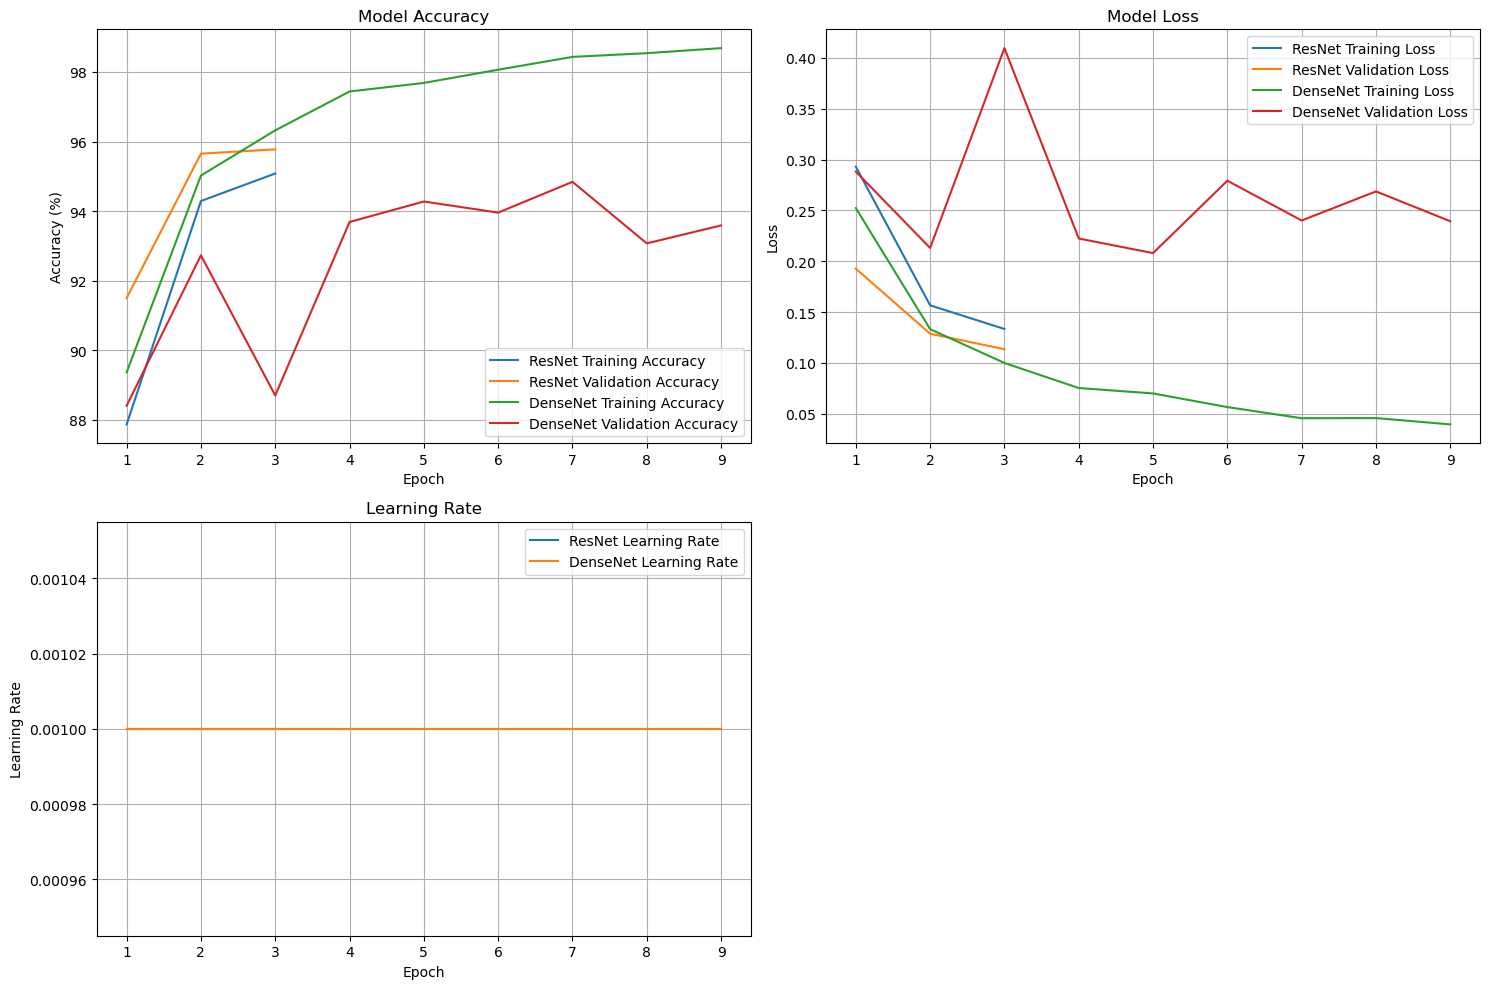

In [15]:
# Plot training metrics
print("Plotting training metrics...")
plot_training_metrics(histories)

In [33]:
# Create test data loader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = DeepfakeDataset('dataset_kaggle/dataset/data/test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

Loading dataset from dataset_kaggle/dataset/data/test
Loading real images...
Loading fake images...
Loaded 4030 images in 0.46 seconds


In [25]:
# Create test data loader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = DeepfakeDataset('dataset/data/test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

Loading dataset from dataset/data/test
Loading real images...
Loading fake images...
Loaded 2930 images in 0.76 seconds


In [29]:
# Evaluate fusion with different weight combinations
print("\nEvaluating fusion with different weight combinations...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Evaluating fusion with different weight combinations...


In [23]:
# Try different weight combinations
weight_combinations = [
    [0.5, 0.5],  # Equal weights
    [0.6, 0.4],  # Slightly favoring ResNet
    [0.4, 0.6],  # Slightly favoring DenseNet
    [0.7, 0.3],  # More favoring ResNet
    [0.3, 0.7]   # More favoring DenseNet
]

best_accuracy = 0
best_weights = None

for weights in weight_combinations:
    print(f"\nTesting weights: ResNet={weights[0]:.1f}, DenseNet={weights[1]:.1f}")
    
    accuracy, predictions, true_labels, results = evaluate_fusion(
        resnet_model, densenet_model, test_loader, device, weights
    )
    
    print(f"Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_weights = weights
        best_results = results
        best_predictions = predictions
        best_true_labels = true_labels


print(f"\nBest performance achieved with weights: ResNet={best_weights[0]:.1f}, DenseNet={best_weights[1]:.1f}")
print(f"Best Accuracy: {best_accuracy:.2f}%")


Testing weights: ResNet=0.5, DenseNet=0.5


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 126/126 [00:48<00:00,  2.60it/s]



✅ Evaluation completed.
accuracy: 93.84615384615384
total_inference_time_sec: 48.565410137176514
inference_time_per_image_sec: 0.012050970257363899
gpu_memory_mb: 408.51953125
cpu_energy_joules: None
cpu_clock_cycles_ns: 48565227500
Accuracy: 93.85%

Testing weights: ResNet=0.6, DenseNet=0.4


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 126/126 [00:47<00:00,  2.66it/s]



✅ Evaluation completed.
accuracy: 94.0198511166253
total_inference_time_sec: 47.37282204627991
inference_time_per_image_sec: 0.011755042691384592
gpu_memory_mb: 407.521484375
cpu_energy_joules: None
cpu_clock_cycles_ns: 47372682200
Accuracy: 94.02%

Testing weights: ResNet=0.4, DenseNet=0.6


...


✅ Evaluation completed.
accuracy: 93.54838709677419
total_inference_time_sec: 46.30080008506775
inference_time_per_image_sec: 0.01148903227917314
gpu_memory_mb: 407.521484375
cpu_energy_joules: None
cpu_clock_cycles_ns: 46300774300
Accuracy: 93.55%

Testing weights: ResNet=0.7, DenseNet=0.3


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 126/126 [00:46<00:00,  2.74it/s]



✅ Evaluation completed.
accuracy: 94.09429280397022
total_inference_time_sec: 46.00757694244385
inference_time_per_image_sec: 0.011416272194154801
gpu_memory_mb: 407.521484375
cpu_energy_joules: None
cpu_clock_cycles_ns: 46007534800
Accuracy: 94.09%

Testing weights: ResNet=0.3, DenseNet=0.7


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 126/126 [00:45<00:00,  2.76it/s]


✅ Evaluation completed.
accuracy: 93.00248138957816
total_inference_time_sec: 45.642815828323364
inference_time_per_image_sec: 0.011325760751445004
gpu_memory_mb: 407.521484375
cpu_energy_joules: None
cpu_clock_cycles_ns: 45642864200
Accuracy: 93.00%

Best performance achieved with weights: ResNet=0.7, DenseNet=0.3
Best Accuracy: 94.09%


In [39]:
# Try different weight combinations
weight_combinations = [
    [0.7, 0.3],  # More favoring ResNet
]

best_accuracy = 0
best_weights = None

for weights in weight_combinations:
    print(f"\nTesting weights: ResNet={weights[0]:.1f}, DenseNet={weights[1]:.1f}")
    
    accuracy, predictions, true_labels, results = evaluate_fusion(
        resnet_model, densenet_model, test_loader, device, weights
    )
    
    print(f"Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_weights = weights
        best_results = results
        best_predictions = predictions
        best_true_labels = true_labels


print(f"\nBest performance achieved with weights: ResNet={best_weights[0]:.1f}, DenseNet={best_weights[1]:.1f}")
print(f"Best Accuracy: {best_accuracy:.2f}%")


Testing weights: ResNet=0.7, DenseNet=0.3


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 126/126 [00:58<00:00,  2.17it/s]


✅ Evaluation completed.
accuracy: 94.09429280397022
total_inference_time_sec: 58.0980064868927
inference_time_per_image_sec: 0.014416378780866676
gpu_memory_mb: 660.0185546875
cpu_energy_joules: None
cpu_clock_cycles_ns: 58097460700
Accuracy: 94.09%

Best performance achieved with weights: ResNet=0.7, DenseNet=0.3
Best Accuracy: 94.09%


In [41]:
# Try different weight combinations
weight_combinations = [
    [0.7, 0.3],  # More favoring ResNet
]

best_accuracy = 0
best_weights = None

for weights in weight_combinations:
    print(f"\nTesting weights: ResNet={weights[0]:.1f}, DenseNet={weights[1]:.1f}")
    
    accuracy, predictions, true_labels, results = evaluate_fusion(
        resnet_model, densenet_model, test_loader, device, weights
    )
    
    print(f"Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_weights = weights
        best_results = results
        best_predictions = predictions
        best_true_labels = true_labels


print(f"\nBest performance achieved with weights: ResNet={best_weights[0]:.1f}, DenseNet={best_weights[1]:.1f}")
print(f"Best Accuracy: {best_accuracy:.2f}%")


Testing weights: ResNet=0.7, DenseNet=0.3


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 126/126 [01:08<00:00,  1.85it/s]


✅ Evaluation completed.
accuracy: 94.09429280397022
total_inference_time_sec: 68.15068817138672
inference_time_per_image_sec: 0.016910840737316805
gpu_memory_mb: 660.0185546875
cpu_energy_joules: None
cpu_clock_cycles_ns: 68155867900
Accuracy: 94.09%

Best performance achieved with weights: ResNet=0.7, DenseNet=0.3
Best Accuracy: 94.09%



Generating confusion matrix for best performing weights...


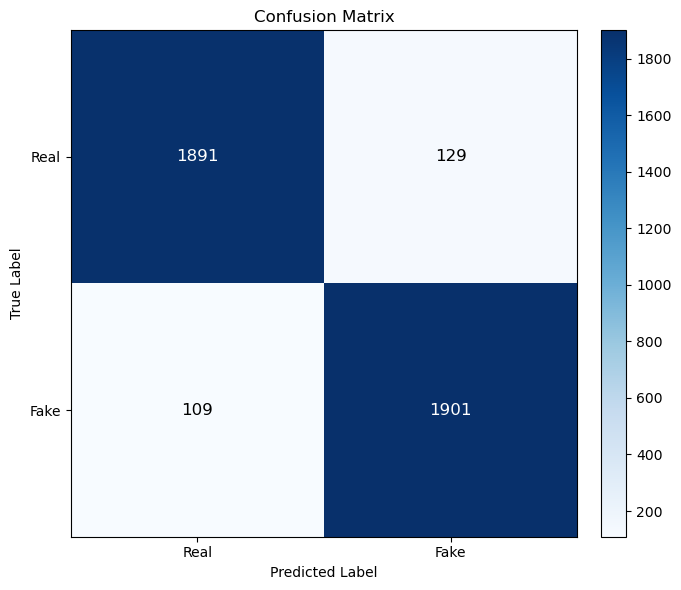


Classification Report:
              precision    recall  f1-score   support

        Real       0.95      0.94      0.94      2020
        Fake       0.94      0.95      0.94      2010

    accuracy                           0.94      4030
   macro avg       0.94      0.94      0.94      4030
weighted avg       0.94      0.94      0.94      4030



In [24]:
print("\nGenerating confusion matrix for best performing weights...")
plot_confusion_matrix(best_true_labels, best_predictions, class_names=['Real','Fake'])
# or ['Real','Fake'] if you prefer names


In [ ]:
# Try different weight combinations
weight_combinations = [
    [0.7, 0.3],  # More favoring ResNet
]

best_accuracy = 0
best_weights = None

for weights in weight_combinations:
    print(f"\nTesting weights: ResNet={weights[0]:.1f}, DenseNet={weights[1]:.1f}")
    
    accuracy, predictions, true_labels, results = evaluate_fusion(
        resnet_model, densenet_model, test_loader, device, weights
    )
    
    print(f"Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_weights = weights
        best_results = results
        best_predictions = predictions
        best_true_labels = true_labels


print(f"\nBest performance achieved with weights: ResNet={best_weights[0]:.1f}, DenseNet={best_weights[1]:.1f}")
print(f"Best Accuracy: {best_accuracy:.2f}%")